In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../dm_xsec_calc/dm_xsec/')
sys.path.append('../')

import rate_massless_mediator as mm
import project_dm_smooth_ana as sm

In [4]:
mx_list_coarser_extended = np.logspace(4, 9, 39)
mx_list_coarse = np.logspace(-1, 4, 77)

alpha_list_coarse = np.logspace(-7, -3, 79)
alpha_list_coarse_extended= np.logspace(-7, 1, 157)

In [5]:
def load_drdq(rate_dir, R_um, mx, alpha, mphi):
    if mphi == 0:
        prefix_mphi = 'massless_mediator'
        append_mphi = 'massless'
    else:
        prefix_mphi = f'mphi_{mphi:.0e}'
        append_mphi = f'{mphi:.0e}'

    file = f'{rate_dir}/{prefix_mphi}/drdq_25mevthr_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{append_mphi}.npz'
    drdq_npz = np.load(file)
    qq = drdq_npz['q_kev']
    drdq = drdq_npz['drdq_hz_kev']

    return qq, drdq

In [75]:
mx_gev = mx_list_coarser_extended[0]
alpha_t = alpha_list_coarse[10]

R_um = 0.083
R = R_um / mm.hbarc       # Sphere radius, eV^-1
N_T = 0.5 * ( 4/3 * np.pi * (R_um*1e-6)**3 ) * mm.rho_T/mm.mAMU # Number of neutrons

mx = mx_gev * 1e9      # DM mass, eV
alpha = alpha_t * N_T  # Total coupling

# pmax = 2.5 * mm.vesc * mx
pmax = 100e7
q  = np.linspace(mm.qmin, pmax, 200000)

vlist = np.linspace(mm.vmin, mm.vesc, mm.nvels)
q_kev, drdq = mm.dR_dq(mx, 0, alpha, q, vlist, R)


In [78]:
qqz, drdqz = sm.get_drdqz(q_kev, drdq)
qqz_truncated_25mev, drdqz_truncated_25mev = sm.get_drdqz(q_kev[q_kev<25000], drdq[q_kev<25000])
qqz_truncated_10mev, drdqz_truncated_10mev = sm.get_drdqz(q_kev[q_kev<10000], drdq[q_kev<10000])

In [79]:
qqz_truncated_10mev

array([    5,    10,    15, ..., 24985, 24990, 24995])

Text(0, 0.5, '$dR/dq$ (Hz/keV/c)')

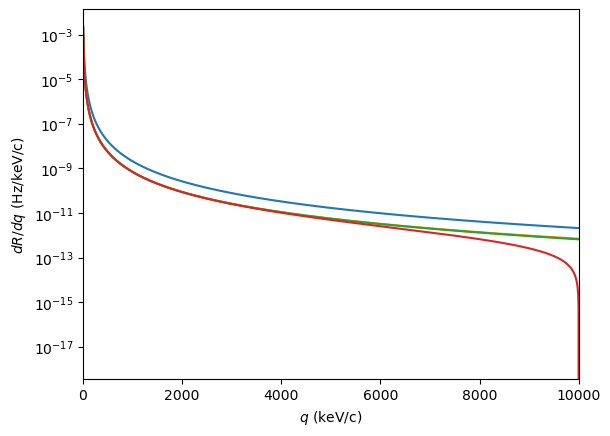

In [83]:
plt.plot(q_kev, drdq)
plt.plot(qqz, drdqz)
plt.plot(qqz_truncated_25mev, drdqz_truncated_25mev)
plt.plot(qqz_truncated_10mev, drdqz_truncated_10mev)


# plt.plot(qqz_truncated_25mev, drdqz[qqz<25000] - drdqz_truncated_25mev)
# plt.plot(qqz_truncated_10mev, drdqz[qqz<10000] - drdqz_truncated_10mev)


plt.xlim(0, 10000)
plt.yscale('log')

plt.xlabel('$q$ (keV/c)')
plt.ylabel('$dR/dq$ (Hz/keV/c)')

In [64]:
rate_dir = '/home/yt388/palmer_scratch/data/dm_rate'
R_um = 0.083

dataset = 'coarse'
mphi = 10

rate_file = f'{rate_dir}/mphi_{mphi:.0e}/drdqz_25mevthr_nanosphere_{R_um:.2e}_{dataset}_{mphi:.0e}.npz'
drdqzn_npz = np.load(rate_file)
bc = drdqzn_npz['bc_kev']
drdqzns = drdqzn_npz['drdqzn']
mx_list = drdqzn_npz['mx_list']
alpha_list = drdqzn_npz['alpha_list']

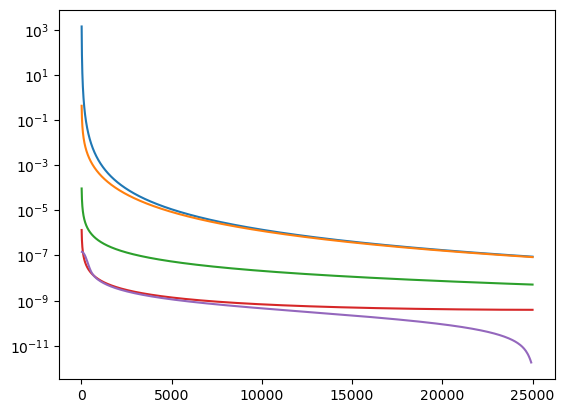

In [67]:
rate_dir = '/home/yt388/palmer_scratch/data/dm_rate'
R_um = 0.083

i_mx = 50
i_alpha = 50

mx_list_coarse = np.logspace(-1, 4, 77)
alpha_list_coarse = np.logspace(-7, -3, 79)

mx, alpha = mx_list_coarse[i_mx], alpha_list_coarse[i_alpha]

qq_massless, drdq_massless = load_drdq(rate_dir, R_um, mx, alpha, 0)
qq_0_01, drdq_0_01 = load_drdq(rate_dir, R_um, mx, alpha, 0.01)
qq_1, drdq_1 = load_drdq(rate_dir, R_um, mx, alpha, 1)
qq_10, drdq_10 = load_drdq(rate_dir, R_um, mx, alpha, 10)

plt.plot(qq_massless, drdq_massless)
plt.plot(qq_0_01, drdq_0_01)
plt.plot(qq_1, drdq_1)
plt.plot(qq_10, drdq_10)

# qqz, drdqz = get_drdqz(qq, drdq)
# qqzn, drdqzn = smear_drdqz_gauss(qqz, drdqz)
# drdqz_smeared_resampled = np.interp(bc, qqzn, drdqzn)
# # bc, _drdqzn = get_final_drdqz(mphi, mx, alpha, 180, True)

# plt.plot(qq, drdq)
# plt.plot(qqz, drdqz)
# plt.plot(qqzn, drdqzn)
# plt.plot(bc, drdqz_smeared_resampled)
plt.plot(bc, drdqzns[i_mx, i_alpha])
    
plt.yscale('log')
# plt.ylim(1e-10, 1e-6)
# plt.xlim(0, 10000)

In [8]:
R_um = 0.083
mx_gev = 1e7
alpha_t = 1e-3

In [9]:
qq, drdq = calc_event_rate(R_um, mx_gev, alpha_t)

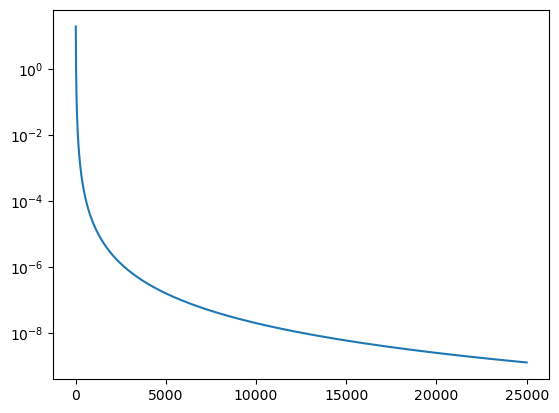

In [11]:
plt.plot(qq, drdq)
plt.yscale('log')

In [4]:
vlist = np.linspace(vmin, vesc, nvels)

In [7]:
vesc

0.001815

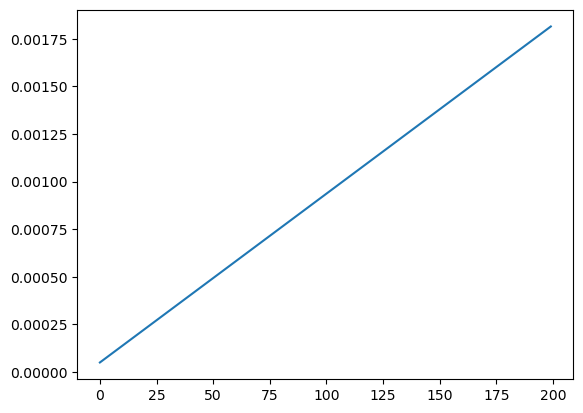

In [6]:
plt.plot(vlist)